# Looming Analysis — Example

Minimal usage of the `looming_analysis` package:

1. Load `.braidz` files grouped by experimental condition.
2. Classify trials as responsive / non-responsive.
3. Plot across the parameter space using the `row_by` / `col_by` / `hue_by` API.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import polars as pl

from looming_analysis import (
    process_all_files,
    process_file_groups,
    classify_responsiveness,
    plot_responses,
    plot_heading_changes,
    plot_responsiveness_rates,
    plot_responses_by_responsiveness,
    plot_peak_velocity,
    compute_turn_direction,
    plot_turn_proportions,
)

/home/nfc/src/looming_analysis/.venv/lib/python3.14/site-packages/pynumdiff/__init__.py:9: UserWarning: tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.
  warn("tvrdiff, robustdiff, and lineardiff not available due to lack of convex solver. To use those, install CVXPY.")


## Single-group analysis

Use `process_all_files` when you have several `.braidz` files from one condition
and just want to compare looming parameters (e.g. `final_size_deg`,
`expansion_duration_ms`, `stimulus_offset_deg`) within that group.

With a single group there is no `hue_by="group"` — instead use all three facet
dimensions for the stimulus parameters themselves.

In [ ]:
# Load all files from one condition — no group label needed
root_folder = "/mnt/data/experiments/"
files = [
    "20260420_171221.braidz",
    "20260421_145231.braidz",
    "20260422_153355.braidz",
]

# append root folder to each file name
files = [root_folder + file for file in files]

single_responses = process_all_files(
    files, pre_frames=-10, post_frames=50, max_gap_frames=5, debug=True
)
classify_responsiveness(single_responses)

Processing /mnt/data/experiments/20260420_171221.braidz...
  [skip] obj_id=1292 frame=391737: 40 missing frames (limit=5)
  [skip] obj_id=2832 frame=511414: 10 missing frames (limit=5)
  [skip] obj_id=8226 frame=629195: 31 missing frames (limit=5)
  [skip] obj_id=11893 frame=723474: 52 missing frames (limit=5)
  [skip] obj_id=17100 frame=766569: 34 missing frames (limit=5)
  [skip] obj_id=21439 frame=792801: 17 missing frames (limit=5)
  [skip] obj_id=28128 frame=967920: 40 missing frames (limit=5)
  [skip] obj_id=30838 frame=1011869: 31 missing frames (limit=5)
  [skip] obj_id=31594 frame=1045976: 8 missing frames (limit=5)
  [skip] obj_id=31773 frame=1049201: 46 missing frames (limit=5)
  [skip] obj_id=32506 frame=1083068: 34 missing frames (limit=5)
  [skip] obj_id=35206 frame=1165991: 7 missing frames (limit=5)
  [skip] obj_id=36488 frame=1217221: 54 missing frames (limit=5)
  [skip] obj_id=39201 frame=1296467: 44 missing frames (limit=5)
  [skip] obj_id=39447 frame=1322527: 40 mis

[{'ang_vel': array([-1.56071436e+00, -1.49517163e+00, -1.41544665e+00, -1.32959516e+00,
         -1.27134486e+00, -1.24771090e+00, -1.24287062e+00, -1.23020501e+00,
         -1.16725095e+00, -9.99825330e-01, -7.06445595e-01, -3.34593155e-01,
          1.42729457e-02,  2.07622674e-01,  8.41584439e-02, -5.48027873e-01,
         -1.92428078e+00, -4.35544531e+00, -8.25256092e+00, -1.40091290e+01,
         -2.14414383e+01, -2.89701020e+01, -3.38135774e+01, -3.38174985e+01,
         -2.91036508e+01, -2.17014924e+01, -1.40172517e+01, -7.83955010e+00,
         -4.13236735e+00, -3.13461437e+00, -4.57173600e+00, -7.89330595e+00,
         -1.23800301e+01, -1.70972159e+01, -2.08984973e+01, -2.27026263e+01,
         -2.19766792e+01, -1.90300669e+01, -1.48505262e+01, -1.06810113e+01,
         -7.60311527e+00, -6.18500583e+00, -6.33794085e+00, -7.47364344e+00,
         -8.74618136e+00, -9.26920548e+00, -8.42889848e+00, -6.17122750e+00,
         -2.97736371e+00,  4.31016537e-01,  3.34773307e+00,  5.17

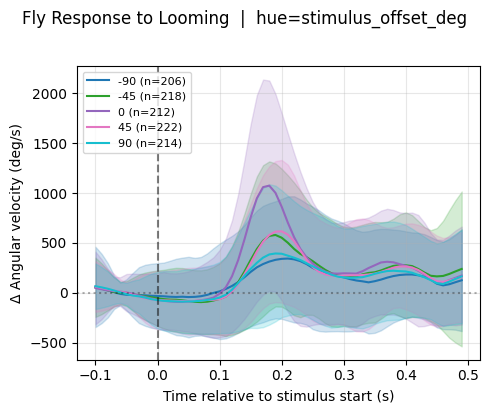

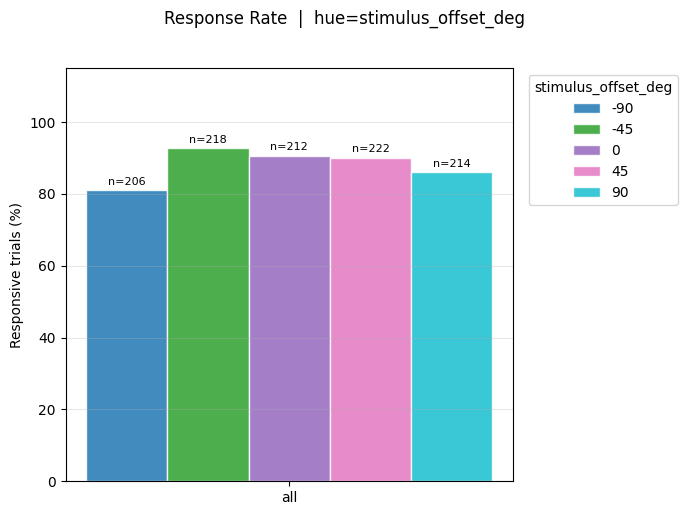

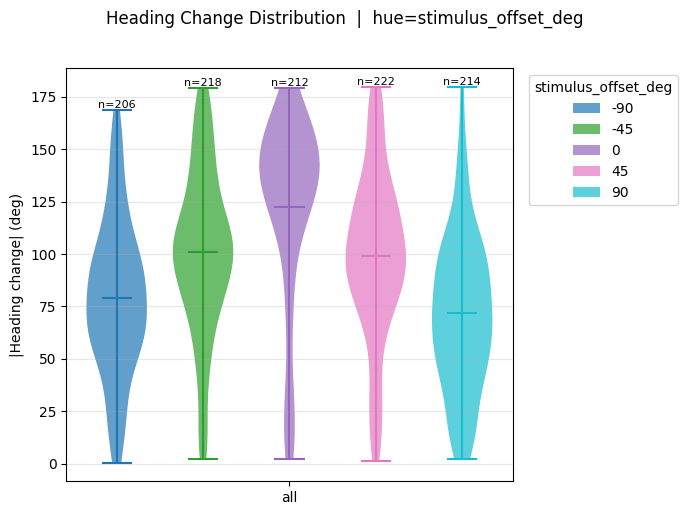

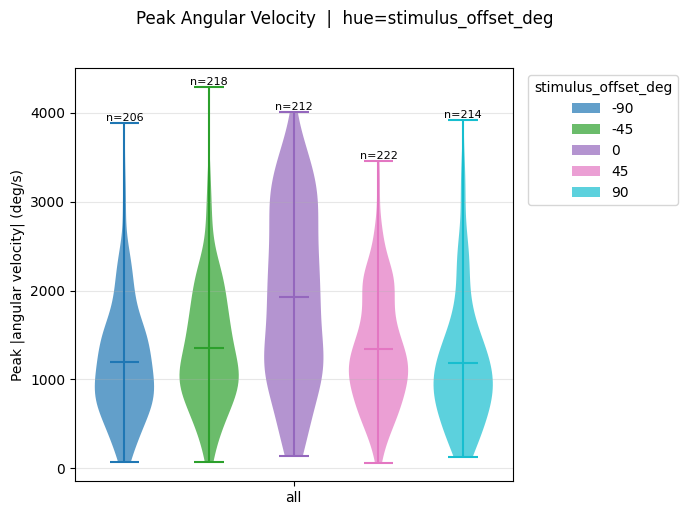

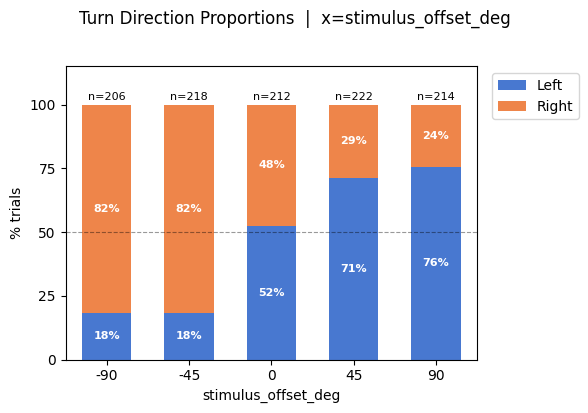

In [3]:
# pre_frames=0 means no pre-stim window, so baseline subtraction has nothing
# to subtract — disable it explicitly to keep the ylabel honest.
fig = plot_responses(
    single_responses,
    hue_by="stimulus_offset_deg",
    baseline_subtract=True,
)

# Responsiveness rate: x = stimulus direction, hue = looming size
fig = plot_responsiveness_rates(
    single_responses,
    hue_by="stimulus_offset_deg",
)

# Heading change distribution: same layout
fig = plot_heading_changes(
    single_responses,
    hue_by="stimulus_offset_deg",
    absolute=True,
)

# Peak velocity distribution: same layout
fig = plot_peak_velocity(
    responses=single_responses,
    hue_by="stimulus_offset_deg",
)
# Turn direction distribution: same layout, but hue = expansion duration
compute_turn_direction(single_responses)
fig = plot_turn_proportions(responses=single_responses, x_by="stimulus_offset_deg")